## Defining CLASS and loading files!

In [13]:
import socket
import os, sys

## For some reason the detached screen part when using Jupyter notebook os enviroment doesn't work! Strange!

In [20]:
# Set the PATH environment variable to match the one in the terminal session
os.environ['PATH'] = '/usr/local/bin:/usr/bin:/bin'
node = 'euclid21'
dir = "/mn/stornext/u3/hassanif/neutrino_niayesh/Analysis/Runs_bulk_velocities_1Aug2023/L_1024_Ngrid_512"
# cmd = f"ssh -t {node} 'cd {dir} && bash Run_all.sh 0 && pwd && screen -ls'"
# cmd =  f"ssh -t {node} 'which screen && pwd'"
cmd = f"ssh -t {node} 'cd {dir} && /usr/bin/screen -dm bash -c \"bash Run_all.sh 0\"  && pwd && screen -ls'"
print(cmd)
! {cmd}

ssh -t euclid21 'cd /mn/stornext/u3/hassanif/neutrino_niayesh/Analysis/Runs_bulk_velocities_1Aug2023/L_1024_Ngrid_512 && /usr/bin/screen -dm bash -c "bash Run_all.sh 0"  && pwd && screen -ls'
/mn/stornext/u3/hassanif/neutrino_niayesh/Analysis/Runs_bulk_velocities_1Aug2023/L_1024_Ngrid_512
There is a screen on:
	32246..euclid21	(Detached)
1 Socket in /var/run/screen/S-hassanif.

Connection to euclid21 closed.


In [14]:
node = 'euclid21'
dir = "/mn/stornext/u3/hassanif/neutrino_niayesh/Analysis/Runs_bulk_velocities_1Aug2023/L_1024_Ngrid_512"
cmd = f"ssh -t {node} 'cd {dir} && nohup bash Run_all.sh 0 &'"
print(cmd)

# Execute the command on the remote server
! {cmd}

ssh -t euclid21 'cd /mn/stornext/u3/hassanif/neutrino_niayesh/Analysis/Runs_bulk_velocities_1Aug2023/L_1024_Ngrid_512 && nohup bash Run_all.sh 0 &'
Connection to euclid21 closed.


In [46]:

# Get the available memory in GB
memory = psutil.virtual_memory().available / (1024 ** 3)
print(f"Host: {hostname}\nAvailable Memory: {memory:.2f} GB")
cpu = os.cpu_count()
print("Host: ",socket.gethostname(),"\ncpus: ",cpu,sep='')

Host: zedaron.uio.no
cpus: 40


In [45]:

# +" '"+zed+"source .bash_login && source .fgevobashrc && module unload python && cd "\
            # +exe+add+" &&  "+run+" "+str(n*m)+' '+str(n)+' '+str(m)+verbose+"'"

In [38]:
sub_box_data_loaded

{'metadata': {'simulation': '0.0ev_L_1024_Ngrid_1024_halos_out_2',
  'boxsize': 1024.0,
  'ngrid': 39,
  'dx': 26.256410256410255,
  'ngrid_min': 35,
  'ngrid_max': 40,
  'ngrid_step': 1,
  'file_path': ['/mn/stornext/u3/hassanif/neutrino_niayesh/simulations/L_1024_Ngrid_1024/0.0ev/output/halos/out_2.list'],
  'bulk_species': ['halo'],
  'save_path': './output/'},
 'sub_box_data': {(0,
   0,
   7): {'sum_bulk_vel': array([ 111.73, 1031.44,  476.52]), 'N': 3},
  (0, 0, 8): {'sum_bulk_vel': array([ -460.14,   320.42, -4885.17]), 'N': 5},
  (18, 2, 4): {'sum_bulk_vel': array([ 613.31,  616.9 , -186.81]), 'N': 1},
  (19, 2, 4): {'sum_bulk_vel': array([ 737.2 , 1921.85, 2070.45]), 'N': 10},
  (19, 2, 5): {'sum_bulk_vel': array([ 1941.49, -2302.81, -1689.56]), 'N': 4},
  (6, 7, 2): {'sum_bulk_vel': array([   215.89,   9006.33, -11250.1 ]),
   'N': 26},
  (14, 2, 0): {'sum_bulk_vel': array([ 3873.31, -3050.7 ,  4259.01]), 'N': 7},
  (15, 2, 0): {'sum_bulk_vel': array([-1861.56,  2741.17, -107

In [2]:


############
# Parsing the settings
############
start_time_all = time.time()
start_mem_all = psutil.Process().memory_info().rss
bulk_species_ini, save_path, file_path, ngrid_min, ngrid_max, ngrid_step, mass_limit = parse_parameters()
ngrid_list = range(ngrid_min, ngrid_max, ngrid_step);
info_files=  generate_new_string(file_path[0])
simulation =info_files[0]
boxsize = np.double(info_files[1])
sim_type = info_files[2]+"ev"
if sim_type=="0.0ev":
    if bulk_species_ini[0] == "nu":
        print_error("In the case of LCDM we don't have nu snapshots!")

obj = analysis.sim(boxsize);
if bulk_species_ini[0] == 'halo':
    pos, vel = load_data(bulk_species_ini[0], file_path[0], obj, mass_limit);       
else:
    pos, vel = load_data(bulk_species_ini[0], file_path[0], obj);       

print("Loading data for bulk species '{}' in simulation '{}' with boxsize '{}'".format(bulk_species_ini[0], file_path[0], boxsize))
print_usage(start_time_all, start_mem_all, ', Data initialized!')



Loading data for bulk species 'halo' in simulation '/mn/stornext/u3/hassanif/neutrino_niayesh/simulations/L_1200_Ngrid_64/0.0ev/output/halos/out_1.list' with boxsize '1200.0'
Walltime: 0.00 seconds, Memory usage: 0.21 MB, Data initialized!


In [37]:
save_path

'./output/'

In [15]:
# ###########
# main part:
# ###########

for ngrid in [3]:
    start_time = time.time()
    start_mem = psutil.Process().memory_info().rss
    df = create_empty_dataframe(['bulk_vel', 'sub_box_index'])
    metadata = {'simulation': simulation, 'boxsize': boxsize, 'ngrid': ngrid, 'dx':  boxsize/ngrid, 'ngrid_min': ngrid_min, 'ngrid_max': ngrid_max, 'ngrid_step': ngrid_step  , 'file_path': file_path, 'bulk_species': bulk_species_ini, 'ngrid': ngrid, 'save_path': save_path}
    
    sub_box_data = {}  # Dictionary to store sub-box data
    for pcl in range(np.shape(pos)[0]):
        x_index = int(np.floor(pos[pcl, 0] * ngrid / boxsize))
        y_index = int(np.floor(pos[pcl, 1] * ngrid / boxsize))
        z_index = int(np.floor(pos[pcl, 2] * ngrid / boxsize))
        sub_box_index = (x_index, y_index, z_index)

        # Check if sub-box exists in the dictionary, if not, initialize it
        if sub_box_index not in sub_box_data:
            sub_box_data[sub_box_index] = {
                'sum_bulk_vel': 0.0,
                'N': 0
            }

        # Accumulate velocity and number of particles in the sub-box
        sub_box_data[sub_box_index]['sum_bulk_vel'] += vel[pcl]
        sub_box_data[sub_box_index]['N'] += 1
    
    # Create a new dictionary that includes both the sub_box_data and the metadata
    data_to_save = {
        'metadata': metadata,
        'sub_box_data': sub_box_data
    }

    # Save the data_to_save dictionary as a binary file using pickle
    save_path_new = f"{metadata['save_path']}/way1_ngrid_{ngrid}_data.pkl"
    with open(save_path_new, 'wb') as file:
        pickle.dump(data_to_save, file);
    
    save_dataframe(sub_box_data, simulation, bulk_species_ini[0] , metadata, ngrid, save_path)
    print_usage(start_time, start_mem, f', n_grid={ngrid} Finished!')


print_usage(start_time_all, start_mem_all, '- Total time and memory!')

Walltime: 0.01 seconds, Memory usage: 0.00 MB, n_grid=3 Finished!
Walltime: 123.84 seconds, Memory usage: 1.86 MB- Total time and memory!


In [12]:
with open("./output/way1_ngrid_3_data.pkl", 'rb') as file:
    way_1_sub_box_data_loaded = pickle.load(file)

In [13]:
with open("./output/data_ngrid_3_sim_0.0ev_L_1200_Ngrid_64_halos_out_1.pickle", 'rb') as file:
    sub_box_data_loaded = pickle.load(file)

In [14]:
way_1_sub_box_data_loaded

{'metadata': {'simulation': '0.0ev_L_1200_Ngrid_64_halos_out_1',
  'boxsize': 1200.0,
  'ngrid': 3,
  'dx': 400.0,
  'ngrid_min': 1,
  'ngrid_max': 2,
  'ngrid_step': 1,
  'file_path': ['/mn/stornext/u3/hassanif/neutrino_niayesh/simulations/L_1200_Ngrid_64/0.0ev/output/halos/out_1.list'],
  'bulk_species': ['halo'],
  'save_path': './output/'},
 'sub_box_data': {(0, 0, 0): {'Σbulk_vel': array([ 120.89,    4.46, -472.78]),
   'N': 8},
  (1, 0, 0): {'Σbulk_vel': array([  636.31, -1730.35, -1048.29]), 'N': 6},
  (0, 0, 1): {'Σbulk_vel': array([ 268.84,  838.06, -462.69]), 'N': 5},
  (0, 1, 1): {'Σbulk_vel': array([ 746.88,   40.23, -169.35]), 'N': 3},
  (0, 1, 0): {'Σbulk_vel': array([ -75.18, -267.03, -562.2 ]), 'N': 4},
  (1, 0, 1): {'Σbulk_vel': array([-1155.08,  -485.47,   423.57]), 'N': 5},
  (0, 0, 2): {'Σbulk_vel': array([233.14, 443.16, 563.46]), 'N': 3},
  (1, 1, 1): {'Σbulk_vel': array([ 105.55,  783.24, -825.  ]), 'N': 3},
  (1, 1, 2): {'Σbulk_vel': array([-1295.94,   -17.37,  

In [9]:
sub_box_data_loaded

{'metadata': {'simulation': '0.0ev_L_1200_Ngrid_64_halos_out_1',
  'boxsize': 1200.0,
  'ngrid': 3,
  'dx': 400.0,
  'ngrid_min': 1,
  'ngrid_max': 2,
  'ngrid_step': 1,
  'file_path': ['/mn/stornext/u3/hassanif/neutrino_niayesh/simulations/L_1200_Ngrid_64/0.0ev/output/halos/out_1.list'],
  'bulk_species': ['halo'],
  'save_path': './output/'},
 'sub_box_data': {(0,
   0,
   0): {'sum_bulk_vel': array([ 120.89,    4.46, -472.78]), 'N': 8},
  (1, 0, 0): {'sum_bulk_vel': array([  636.31, -1730.35, -1048.29]), 'N': 6},
  (0, 0, 1): {'sum_bulk_vel': array([ 268.84,  838.06, -462.69]), 'N': 5},
  (0, 1, 1): {'sum_bulk_vel': array([ 746.88,   40.23, -169.35]), 'N': 3},
  (0, 1, 0): {'sum_bulk_vel': array([ -75.18, -267.03, -562.2 ]), 'N': 4},
  (1, 0, 1): {'sum_bulk_vel': array([-1155.08,  -485.47,   423.57]), 'N': 5},
  (0, 0, 2): {'sum_bulk_vel': array([233.14, 443.16, 563.46]), 'N': 3},
  (1, 1, 1): {'sum_bulk_vel': array([ 105.55,  783.24, -825.  ]), 'N': 3},
  (1, 1, 2): {'sum_bulk_vel'

In [67]:
sub_box_data_loaded[0,0,0]

{'bulk_vel': array([ 120.89,    4.46, -472.78]), 'N': 8}

In [75]:
condition_x = (np.floor(pos[:,0]*ngrid/boxsize)== 0)
condition_y = (np.floor(pos[:,1]*ngrid/boxsize)== 0)
condition_z = (np.floor(pos[:,2]*ngrid/boxsize)== 0)
condition_tot = (condition_x) & (condition_y) & (condition_z)
vel_halos =vel[condition_tot];
np.mean(vel_halos[:,2])

-59.0975

In [55]:
np.average(vel[:,1])

0.5911881188118883

In [56]:
np.average(vel[:,2])

-11.186831683168318

In [15]:
tree.key

AttributeError: 'KDTree' object has no attribute 'key'

In [6]:
mass_limit

50000000000000.0

In [2]:
snap_cdm_string="a//sk//jdnsdkjfsd//.out"
snap_cdm_string = snap_cdm_string.rstrip('/').replace('.out', '')

In [3]:
snap_cdm_string

'a//sk//jdnsdkjfsd//'

In [3]:
simulation

'0.6ev_L_1200_Ngrid_64_snap003_cdm'

In [75]:
print(match_parts('/mn/stornext/u3/hassanif/neutrino_niayesh/simulations/L_1024_Ngrid_512/0.6ev//output/snap002_cdm'))

None


In [ ]:
'/mn/stornext/u3/hassanif/neutrino_niayesh/simulations/L_1200_Ngrid_64/0.0ev/output/halos/out_3.list/

In [65]:
np.average(halos[:,13])

-3.1579024266294002

In [37]:
np.average(vel[:,0]),np.average(vel[:,1]),np.average(vel[:,2])

(-0.36160326, -0.4650362, 0.2859323)

In [11]:
import pickle

with open('./output/data_ngrid_3_sim_0.0ev_L_1200_Ngrid_64_halos_out_3_.pickle', 'rb') as handle:
    data = pickle.load(handle)

In [60]:
data['bulk_vel'][0]

array([ 8.99955914,  2.45410494, -3.15790243])

In [25]:
np.shape(vel)

(16777216, 3)

In [31]:
np.std((vel[:,1]))

271.7061

In [33]:
np.average((vel[:,1]))

0.020264905

In [29]:
data

,bulk_vel,sub_box_index,Number of particles in the cell,bulk_vel_error
0,"[-0.020007499, 0.020294635, -0.013548365]","[0, 0, 0]",16777214.0,"[281.50446, 271.70605, 274.3596]"


In [74]:
data['bulk_vel']

0    [-0.82466865, 1.1499444, -7.640324]
Name: bulk_vel, dtype: object

In [ ]:
/mn/stornext/u3/hassanif/neutrino_niayesh/simulations/L_1024_Ngrid_64/0.6ev/output/snap003_cdm

In [6]:
print(f"\033[1m\033[94m Ngrid:"+str(ngrid)+"\033[0m")

 Ngrid:3


In [12]:
from mpi4py import MPI
import numpy as np
import sys
sys.path.append('/mn/stornext/u3/hassanif/neutrino_niayesh/Analysis/nu_code/')
from functions import parse_parameters
from functions import load_data
from functions import print_error
from functions import print_usage
from functions import create_empty_dataframe
from functions import get_simulation_parameters
from functions import save_dataframe
from multiprocessing import Lock
import pickle
import numpy as np
import pandas as pd
import os
from library_snapshot import sim_analysis as analysis
import time
import psutil
## To run mpirun -n 4 main_bulk.py
############
# MPI
############
# lock = Lock()
# comm = MPI.COMM_WORLD
# rank = comm.Get_rank()
# n_cores = comm.Get_size()

############
# Parsing the settings
############
start_time_all = time.time()
start_mem_all = psutil.Process().memory_info().rss
simulation, bulk_species_ini, save_path, file_path, ngrid_min, ngrid_max, ngrid_step = parse_parameters()
ngrid_list = range(ngrid_min, ngrid_max, ngrid_step);
boxsize = np.double(get_simulation_parameters(simulation[0])['L'])
sim_type = get_simulation_parameters(simulation[0])['sim_type']+"ev"
if sim_type=="0.0ev":
    if bulk_species_ini[0] == "nu":
        print_error("In the case of LCDM we don't have nu snapshots!")

obj = analysis.sim(boxsize);        
pos, vel = load_data(bulk_species_ini[0], file_path[0], obj);   
pos = pos[::1000000]
vel = vel[::1000000]
# if rank==0:
#     print("Loading data for bulk species '{}' in simulation '{}'".format(bulk_species_ini[0], file_path[0]))
#     print_usage(start_time_all, start_mem_all, ', Data initialized!')
#     print("Number of cores being used:", n_cores)


In [16]:
pos.max()

1199.1154

In [3]:
for ngrid in [1]:
    sub_box_lists = obj.All_sub_box(ngrid)
    n_subboxes = len(sub_box_lists)
    df = create_empty_dataframe(['bulk_vel', 'sub_box_index'])
    metadata = {'simulation': simulation, 'boxsize': boxsize, 'ngrid': ngrid, 'dx':  boxsize/ngrid, 'ngrid_min': ngrid_min, 'ngrid_max': ngrid_max, 'ngrid_step': ngrid_step  , 'file_path': file_path, 'bulk_species': bulk_species_ini, 'ngrid': ngrid, 'save_path': save_path}
    
    for sub_box_index in sub_box_lists:
        bulk_vel_i = obj.velocity_bulk(ngrid, pos, vel, sub_box_index)
        print(sub_box_index, sub_box_lists, bulk_vel_i)
        # data_saved = {
        #     'bulk_vel': bulk_vel_i[0],
        #     'bulk_vel_error': bulk_vel_i[1],
        #     'Number of particles in the cell': bulk_vel_i[2],
        #     'sub_box_index': sub_box_index
        # }
#         df = df.append(data_saved, ignore_index=True)

#     if rank == 0:
#         df = pd.concat(all_data, ignore_index=True)
#         save_dataframe(df, simulation[0], metadata, ngrid, save_path)
#         print_usage(start_time, start_mem, ', n_grid= ' + str(ngrid) + ' Finished!')

#     # Clear dataframe before processing next ngrid
#     df = None

# if rank == 0:   
#     print_usage(start_time_all, start_mem_all, '- Total time and memory!')

1024.0
[0, 0, 0] [[0, 0, 0]] [array([-0.82466865,  1.1499444 , -7.640324  ], dtype=float32), array([284.3601 , 274.2771 , 274.15182], dtype=float32), 10424165]


In [ ]:
"/mn/stornext/u3/hassanif/neutrino_niayesh/simulations/L_1024_Ngrid_64/0.6ev/output/snap003_cdm"

In [5]:
simulation

['0.0ev_L_1024_Ngrid_512_snap002_cdm']

In [26]:

sim_detail

NameError: name 'sim_detail' is not defined

In [1]:
from mpi4py import MPI
import numpy as np
import sys
sys.path.append('/mn/stornext/u3/hassanif/neutrino_niayesh/Analysis/nu_code/')
from functions import parse_parameters
from functions import load_data
from functions import print_error
from functions import print_usage
from functions import create_empty_dataframe
from functions import get_simulation_parameters
from functions import save_dataframe
from multiprocessing import Lock
import pickle
import numpy as np
import pandas as pd
import os
from library_snapshot import sim_analysis as analysis
import time
import psutil

############
# MPI
############
# lock = Lock()
# comm = MPI.COMM_WORLD
# rank = comm.Get_rank()
# n_cores = comm.Get_size()

############
# Parsing the settings
############
start_time_all = time.time()
start_mem_all = psutil.Process().memory_info().rss
simulation, boxsize, bulk_species_ini, save_path, file_path, ngrid_min, ngrid_max, ngrid_step = parse_parameters()
ngrid_list = range(ngrid_min, ngrid_max, ngrid_step);
# get_simulation_parameters(simulation_name)

ValueError: not enough values to unpack (expected 8, got 7)

In [5]:
if __name__ == "__main__":
  simulation_name = "0.0ev_L_1024_Ngrid_512_snap002_cdm"
  parameters = get_simulation_parameters(simulation_name)

  print(parameters['sim_type'])

0.0


In [7]:
bulk_species = bulk_species_ini[0]
sim_path = file_path[0]
print("Loading data for bulk species '{}' in simulation '{}'".format(bulk_species, sim_path))

Loading data for bulk species 'cdm' in simulation '/mn/stornext/u3/hassanif/neutrino_niayesh/simulations/L_1024_Ngrid_512/0.0ev/output/snap002_cdm'


In [3]:
file_path[0]

'/mn/stornext/u3/hassanif/neutrino_niayesh/simulations/L_1024_Ngrid_512/0.0ev/output/snap002_cdm'

In [4]:
parse_parameters()

(['L_1024_Ngrid_512'],
 1024.0,
 ['cdm'],
 [2],
 ['0.0ev'],
 './output/',
 ['/mn/stornext/u3/hassanif/neutrino_niayesh/simulations/L_1024_Ngrid_512/0.0ev/output/snap002_cdm'],
 10,
 11,
 1)

In [6]:
"/mn/stornext/u3/hassanif/neutrino_niayesh/simulations/L_1024_Ngrid_512/0.0ev/output/snap002_cdm"

'/mn/stornext/u3/hassanif/neutrino_niayesh/simulations/Neutrino_runs_JulianAdamek/nu300meV_2048box_4096_snap004_halos_parents.dat'

In [24]:
sub_box_lists

[[0, 0, 1], [0, 1, 0], [0, 1, 1]]

In [121]:
with open('./output/data_ngrid_20_sim_L_2048_Ngrid_4096_0.3ev_snap_4.pickle','rb') as handle:
    df = pickle.load(handle)
# with open('./output/data_ngrid_6_sim_L_2048_Ngrid_4096_0.3ev_snap_4.pickle','rb') as handle:
#     df_p = pickle.load(handle)


In [124]:
df[df['sub_box_index'].apply(lambda x: x == [0, 0, 0])].iloc[0]['halo_vel']

array([[ 27391.44,  52640.9 ,  17127.58],
       [ 28535.35,  51462.46,  17600.74],
       [ 28687.51,  52976.07,  17235.18],
       [  9703.83,  59212.64,  12192.46],
       [  8855.81,  59789.44,  11746.93],
       [  8881.55,  60220.34,  11716.96],
       [  8740.56,  61227.75,   9699.3 ],
       [  8445.05,  61689.89,   9715.68],
       [  8804.96,  60712.58,  11332.48],
       [  9367.41,  60298.6 ,  10888.49],
       [  8617.41,  61369.75,  10273.34],
       [  8617.09,  61302.47,  10753.67],
       [ 92544.79,  70698.23,  20732.72],
       [ 95631.53,  72145.16,  19144.95],
       [ 94386.78,  69681.77,  23709.09],
       [ 94530.7 ,  69339.99,  24751.41],
       [ 26898.3 ,  18820.55,  16547.69],
       [ 30109.35,  17978.95,  17982.96],
       [ 32444.65,  18806.48,  18753.95],
       [  9248.63,   7868.16,  17486.34],
       [ 10140.04,   8384.74,  16638.88],
       [ 86233.19,   7442.75,  44702.68],
       [ 66788.8 ,  38267.14,  74294.97],
       [ 65961.7 ,  38703.25,  769

In [110]:
df['halo_mass'][2]==df_p['halo_mass'][2]

array([ True,  True,  True, ...,  True,  True,  True])

In [102]:
comparison = (df['sub_box_index'] == df_p['sub_box_index']).all()
# comparison = (df['halo_vel'] == df_p['halo_vel']).all()
# comparison = (df['halo_mass'][0] == df_p['halo_mass'][0]).all()
# comparison = (df['bulk_vel'][0] == df_p['bulk_vel'][0]).all()


if comparison:
    print("All elements are equal")
else:
    print("Some elements are different")

All elements are equal


In [51]:
df['halo_mass'] 

0     [236180000000000.0, 1428200000000000.0, 445450...
1     [28179000000000.0, 58897000000000.0, 174150000...
2     [122960000000000.0, 1441900000000000.0, 857060...
3     [54243000000000.0, 70406000000000.0, 108150000...
4     [119990000000000.0, 83099000000000.0, 29872000...
                            ...                        
59    [59743000000000.0, 58559000000000.0, 197850000...
60    [172710000000000.0, 75314000000000.0, 78699000...
61    [250990000000000.0, 415240000000000.0, 1777100...
62    [68375000000000.0, 659120000000000.0, 13125000...
63    [95116000000000.0, 196150000000000.0, 25818000...
Name: halo_mass, Length: 64, dtype: object

In [68]:
df

,halo_vel,halo_mass,bulk_vel,halo_pos,sub_box_index
0,"[[455089.94, 449746.09, 422823.41], [454805.62...","[236180000000000.0, 1428200000000000.0, 445450...","[253765.76129440838, 252200.67237514158, 25498...","[[449.69705, 422.85663, 455.09814], [449.05725...","[0, 0, 0]"
1,"[[555267.75, 407793.78, 507771.41], [559023.5,...","[28179000000000.0, 58897000000000.0, 174150000...","[772658.5205572542, 262775.13391557353, 259368...","[[407.81857, 507.77173, 555.27515], [406.06705...","[0, 0, 1]"
2,"[[1024830.06, 197232.3, 20716.76], [1024407.06...","[122960000000000.0, 1441900000000000.0, 857060...","[1284380.4981118299, 256869.8710869352, 254944...","[[197.2229, 20.71978, 1024.84167], [196.34383,...","[0, 0, 2]"
3,"[[1995843.62, 61326.45, 482887.38], [1999123.2...","[54243000000000.0, 70406000000000.0, 108150000...","[1797766.9173089569, 251149.9347650837, 256911...","[[61.26617, 482.89587, 1995.84204], [60.85214,...","[0, 0, 3]"
4,"[[225311.38, 170807.05, 962812.75], [225063.38...","[119990000000000.0, 83099000000000.0, 29872000...","[248710.39684393007, 256533.65085555497, 77348...","[[170.84886, 962.83606, 225.31683], [169.98207...","[0, 1, 0]"
...,...,...,...,...,...
59,"[[1984857.75, 1779272.5, 1432257.25], [1985940...","[59743000000000.0, 58559000000000.0, 197850000...","[1790486.0273617993, 1793112.4868283137, 12806...","[[1779.21667, 1432.21582, 1984.84729], [1778.2...","[3, 2, 3]"
60,"[[116982.62, 1605749.12, 1651770.88], [112322....","[172710000000000.0, 75314000000000.0, 78699000...","[252483.63470876188, 1789763.4385240308, 17949...","[[1605.70093, 1651.78955, 116.97972], [1605.56...","[3, 3, 0]"
61,"[[999337.19, 1930881.5, 1856286.62], [999788.9...","[250990000000000.0, 415240000000000.0, 1777100...","[766477.2181845543, 1792093.906245154, 1788977...","[[1930.92102, 1856.28711, 999.31415], [1931.60...","[3, 3, 1]"
62,"[[1024927.56, 1769237.5, 1732058.5], [1025282....","[68375000000000.0, 659120000000000.0, 13125000...","[1277669.6773482894, 1788501.0333022014, 17816...","[[1769.17151, 1732.04858, 1024.95471], [1769.1...","[3, 3, 2]"


In [45]:
import pandas as pd

diff = a.compare(b)
print(diff)

AttributeError: 'numpy.ndarray' object has no attribute 'compare'

In [39]:
a == b

array([[ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True],
       ...,
       [ True,  True,  True],
       [ True,  True,  True],
       [ True,  True,  True]])

In [26]:
# main part:
start_time = time.time()
start_mem = psutil.Process().memory_info().rss

for ngrid in [4]: 
    sub_box_lists = obj.All_sub_box(ngrid);
    df = create_empty_dataframe(['halo_vel', 'halo_mass', 'bulk_vel' ,'halo_pos', 'sub_box_index']);
    
    for i in range(np.shape(sub_box_lists)[0]):
        sub_box_index = sub_box_lists[i]
        halos_i = obj.halos_in_cell(ngrid, pos, vel, mass, sub_box_index) # Gives the information of halos in a cell defined by sub-box index!
        bulk_vel_halos_i = obj.velocity_bulk(ngrid, pos, vel, sub_box_index)[:3] # Bulk velocities using halos
        data_saved = {
            'halo_vel':halos_i[:,3:6],
            'halo_mass':halos_i[:,6],
            'bulk_vel':bulk_vel_halos_i[0],
            'halo_pos': halos_i[:,0:3],
            'sub_box_index': sub_box_index
              }
        df = df.append(data_saved, ignore_index=True)
        # print_usage(start_time, start_mem, 'sub_box='+str(i))

    save_dataframe(df, sim_size_ini, boxsize, ngrid, bulk_species_ini, snap_num_ini, sim_type_ini, save_path, sim_path, ngrid_min, ngrid_max, ngrid_step, halo_file, n_cores)
    print_usage(start_time, start_mem, ', n_grid= '+str(ngrid)+' Finished!')


Walltime: 7.53 seconds, Memory usage: 4.97 MB, n_grid= 4 Finished!


In [10]:
# sub_box_lists = obj.All_sub_box(ngrid);
def All_sub_box(ngrid):
    """
    Given the number of grids this function generates and returns all sub-box indices.

    Parameters:
        ngrid (int): number of grids in the simulation
        
    Returns:
        A tuple of length ngrid^3 containing all sub-box indices.
    """
    indices=[]
    for i in range(ngrid):
        for j in range(ngrid):
            for k in range(ngrid):
                indices.append((i, j, k))    
    return tuple(indices)



In [11]:
All_sub_box(3)

((0, 0, 0),
 (0, 0, 1),
 (0, 0, 2),
 (0, 1, 0),
 (0, 1, 1),
 (0, 1, 2),
 (0, 2, 0),
 (0, 2, 1),
 (0, 2, 2),
 (1, 0, 0),
 (1, 0, 1),
 (1, 0, 2),
 (1, 1, 0),
 (1, 1, 1),
 (1, 1, 2),
 (1, 2, 0),
 (1, 2, 1),
 (1, 2, 2),
 (2, 0, 0),
 (2, 0, 1),
 (2, 0, 2),
 (2, 1, 0),
 (2, 1, 1),
 (2, 1, 2),
 (2, 2, 0),
 (2, 2, 1),
 (2, 2, 2))

In [12]:
for sub_box_index in sub_box_lists:
    i, j, k = sub_box_index
    print(i)

0
0
0
0
1
1
1
1


In [17]:
with open('./output/data_ngrid_2_sim_L_2048_Ngrid_4096_0.3ev_snap_4.pickle','rb') as handle:
    df = pickle.load(handle)


In [1]:
from mpi4py import MPI
import numpy as np
from functions import parse_parameters
from functions import load_data
from functions import print_usage
from functions import create_empty_dataframe
from functions import save_dataframe
from multiprocessing import Lock
import pickle
import numpy as np
import pandas as pd
import os
from library_snapshot import sim_analysis as analysis
import time
import psutil

############
# MPI
############
lock = Lock()
comm = MPI.COMM_WORLD
rank = comm.Get_rank()
n_cores = comm.Get_size()

############
# Parsing the settings
############
start_time = time.time()
start_mem = psutil.Process().memory_info().rss
sim_size_ini, boxsize, bulk_species_ini, snap_num_ini, sim_type_ini, \
save_path, sim_path, ngrid_min, ngrid_max, ngrid_step, halo_file = parse_parameters()
ngrid_list = range(ngrid_min, ngrid_max, ngrid_step);
obj = analysis.sim(boxsize);
pos, vel, mass = load_data(sim_size_ini[0], sim_type_ini[0], bulk_species_ini[0], snap_num_ini[0], sim_path, halo_file, obj, verbose=False);
if rank==0:
    print_usage(start_time, start_mem, ', Data initialized!')
    print("Number of cores being used:", n_cores)
    

############
# main part:
############
start_time = time.time()
start_mem = psutil.Process().memory_info().rss
from mpi4py import MPI
import numpy as np

# main part:
start_time = time.time()
start_mem = psutil.Process().memory_info().rss


for ngrid in ngrid_list:
    if n_cores > 1:
        # Distribute sub-boxes over cores
        n_subboxes = np.power(ngrid, 3)
        subbox_per_core = int(np.ceil(n_subboxes / n_cores))
        start_index = subbox_per_core * rank
        end_index = min(subbox_per_core * (rank + 1), n_subboxes)
        sub_box_lists = range(start_index, end_index)
    else:
        sub_box_lists = obj.All_sub_box(ngrid)
    
    df = create_empty_dataframe(['halo_vel', 'halo_mass', 'bulk_vel', 'halo_pos', 'sub_box_index'])

    for sub_box_index in sub_box_lists:
        halos_i = obj.halos_in_cell(ngrid, pos, vel, mass, sub_box_index)
        bulk_vel_halos_i = obj.velocity_bulk(ngrid, pos, vel, sub_box_index)[:3]
        data_saved = {
            'halo_vel': halos_i[:,3:6],
            'halo_mass': halos_i[:,6],
            'bulk_vel': bulk_vel_halos_i[0],
            'halo_pos': halos_i[:,0:3],
            'sub_box_index': sub_box_index
        }
        df = df.append(data_saved, ignore_index=True)

    if n_cores > 1:
        # Barrier to ensure all cores have completed their calculations
        comm.Barrier()

        # Concatenate data from all cores
        all_data = comm.gather(df, root=0)

        if rank == 0:
            df = pd.concat(all_data, ignore_index=True)
            save_dataframe(df, sim_size_ini, boxsize, ngrid, bulk_species_ini, snap_num_ini, sim_type_ini, save_path, sim_path, ngrid_min, ngrid_max, ngrid_step, halo_file)
            print_usage(start_time, start_mem, ', n_grid= ' + str(ngrid) + ' Finished!')
    else:
        save_dataframe(df, sim_size_ini, boxsize, ngrid, bulk_species_ini, snap_num_ini, sim_type_ini, save_path, sim_path, ngrid_min, ngrid_max, ngrid_step, halo_file)
        print_usage(start_time, start_mem, ', n_grid= ' + str(ngrid) + ' Finished!')

    # Clear dataframe before processing next ngrid
    df = None

Walltime: 5.99 seconds, Memory usage: 68.73 MB, Data initialized!
Number of cores being used: 1
Walltime: 1.29 seconds, Memory usage: 101.94 MB, n_grid= 2 Finished!


In [4]:
sub_box_lists

range(2, 7)

In [2]:
# n_subboxes = np.power(ngrid, 3)
# subbox_per_core = int(np.ceil(n_subboxes / n_cores))
# start_index = subbox_per_core * rank
# end_index = min(subbox_per_core * (rank + 1), n_subboxes)
sub_box_lists = range(2, 7)

In [ ]:
sub_box_lists

range(2, 7)

In [18]:
gg['sub_box_index']

0      [0, 0, 0]
1      [0, 0, 1]
2      [0, 0, 2]
3      [0, 0, 3]
4      [0, 1, 0]
         ...    
251    [3, 2, 3]
252    [3, 3, 0]
253    [3, 3, 1]
254    [3, 3, 2]
255    [3, 3, 3]
Name: sub_box_index, Length: 256, dtype: object

In [74]:
# dattrsf['sub_box_index'].apply(lambda x: x == [0, 0, 0])]['halo_vel'][0].shape




(46977, 3)

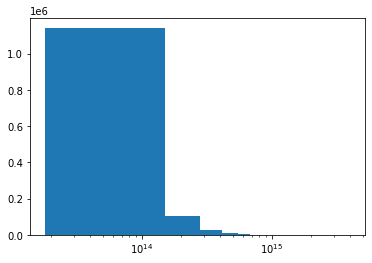

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# plt.hist(np.sqrt(vel[:,0]**2+vel[:,1]**2+vel[:,2]**2))
# plt.hist(vel[:,1], bins=30)
# plt.hist(vel[:,2], bins=30)
plt.hist(mass[:], bins=30)


In [ ]:

for sim_size in sim_size_ini: 
    for bulk_species in bulk_species_ini: 
        for sim in sim_type_ini:
            for snap_num in snap_num_ini: 
                load_data(sim_size, sim, bulk_species, snap_num, sim_path, halo_file, verbose=True);
                ##########
                ##########
                for ngrid in ngrid_ini: 
                    number_smaples = ngrid*ngrid*ngrid;
#                     sub_box_lists = obj.Random_sub_box(ngrid,number_smaples_tmp);
                    sub_box_lists = obj.All_sub_box(ngrid);
                    ## Reseting the dictionary!
                    column_names = ['simulation','parameters','bulk_species','n_grid', 'sub_box_index','bulk_vel_halos_i', 'halos_vel_i']
                    df = pd.DataFrame(columns=column_names)
                    for i in range(number_smaples):
                        sub_box_index = sub_box_lists[i]
#                        ##############################
#                        ##### All halos velocities in each cell
#                        ##############################
                        halos_i = obj.halos_in_cell(ngrid, pos, vel, mass, sub_box_index)# Gives the information of objects in a cell defined by sub-box index!

                        #########################################
                        ### Bulk velocity computation in grid i
                        #########################################
                        bulk_vel_halos_i = obj.velocity_bulk(ngrid, halo_all[:,:3], halo_all[:,3:6], sub_box_index)[:3] # Bulk velocities using halos

                        ##############################
                        ## Here in each cell we compute <vi^p1.v_b> and <v^p2.v_b>
                        ##############################
#                         vdvb_p1_bulk_halos = obj.sum_vel_dot_vbulk(halo_p1_vels_i, bulk_vel_halos_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!
#                         vdvb_p2_bulk_halos = obj.sum_vel_dot_vbulk(halo_p2_vels_i, bulk_vel_halos_i[0]);

#                         vdvb_p1_bulk_cdm = obj.sum_vel_dot_vbulk(halo_p1_vels_i, bulk_vel_cdm_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!
#                         vdvb_p2_bulk_cdm = obj.sum_vel_dot_vbulk(halo_p2_vels_i, bulk_vel_cdm_i[0]);

#                         vdvb_all_bulk_cdm = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_cdm_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!
#                         vdvb_all_bulk_halos = obj.sum_vel_dot_vbulk(halos_vels_i, bulk_vel_halos_i[0]); # This results in an array containing average of <v_i, v_b>, standard deviation and the number of halos in each cell!

                    #     data_saved = {
                    #         'simulation':sim,
                    #         'parameters':parameters,
                    #         'bulk_species':bulk_species,
                    #         'n_grid': ngrid,
                    #         'sub_box_index': sub_box_index,
                    #         'bulk_vel_halos_i': bulk_vel_halos_i,
                    #         'bulk_vel_i': bulk_vel_cdm_i,
                    #         'vp1.v_b':vdvb_p1_bulk_cdm ,
                    #         'vp2.v_b':vdvb_p2_bulk_cdm ,
                    #         'vp1.v_b(halos)':vdvb_p1_bulk_halos ,
                    #         'vp2.v_b(halos)':vdvb_p2_bulk_halos ,
                    #         'v_h.v_b':vdvb_all_bulk_cdm ,
                    #         'v_h.v_b(halos)':vdvb_all_bulk_halos 
                    #         }
                    #     df = df.append(data_saved, ignore_index=True)
                    # if not os.path.exists(save_path):
                    #     os.makedirs(save_path)
                    # with open(save_path+'/data_ngrid_'+str(ngrid)+'_sim_'+sim_size+'_'+sim+'_snap_'+str(snap_num)+'_Nsubboxes_'+str(number_smaples_tmp)+'.pickle', 'wb') as handle:
                    #     pickle.dump(df, handle, protocol=pickle.HIGHEST_PROTOCOL)
                    # print("\t \t *** number of grid: "+str(ngrid)+" is finished!")
            print("\033[34m \033[1m  \n \t The main loop is finished \033[0m")
            print("\033[34m \033[1m ************************************************* \033[0m")



In [82]:
# with open('./output/data_ngrid_3_sim_L_2048_Ngrid_4096_0.3ev_snap_4.pickle','rb') as handle:
#     df = pickle.load(handle)
# df[df['sub_box_index'].apply(lambda x: x == [1, 2, 1])].iloc[0]['halo_vel']



